---
title: "Clasificacion de Sistemas de EDO lineales homogeneas de dimension 2 con Python"
author:
  - name: Luis E. Ascencio G. 
    orcid: 0009-0009-1694-5993
    email: luis.ascencio@cimat.mx
    affiliation: 
      - name: CIMAT
        city: Guanajuato
        state: Guanajuato
        url: https://www.cimat.mx
abstract: > 
 En este NoteBook encontraras codigo para manejar EDO con el lenguaje de programacion Python.
keywords:
  - Sistemas de Ecuaciones Diferenciales Ordinarias
  - Metodos Numericos
  - Campos Vectoriales 
  - Curvas Integrales 
license: "CC BY"
copyright: 
  holder: Luis E. Ascencio G.
  year: 2026
citation: 
  container-title: CIMAT
  volume: 1
  issue: 1
  doi: 000000/00000000
funding: "-"
format:
  pdf:
    documentclass: scrartcl
    toc: true
    number-sections: true
    colorlinks: true
---

  📁  Figures will be saved to: /home/leag555/Escritorio/lasalle/code/py-jl-Differential-Equiations/ode_figures

╔══════════════════════════════════════════════════════════════════╗
║   CLASSIFICATION OF 2D LINEAR ODE SYSTEMS   dx/dt = Ax          ║
║   Educational Phase Portrait Visualizer                          ║
╚══════════════════════════════════════════════════════════════════╝


═════════════════════════════════════════════════════════════════
  GROUP A — DISTINCT REAL EIGENVALUES
═════════════════════════════════════════════════════════════════

  ◆  Unstable Node (Source)

  ┌────────────────────────────────────────────────────────┐
  │                        Matrix A                        │
  ├────────────────────────────────────────────────────────┤
  │   ⎡  +2.0000    +1.0000 ⎤                         │
  │   ⎣  +0.0000    +3.0000 ⎦                         │
  ├────────────────────────────────────────────────────────┤
  │  tr(A) = +5.0000      det(A) = +6.0000             

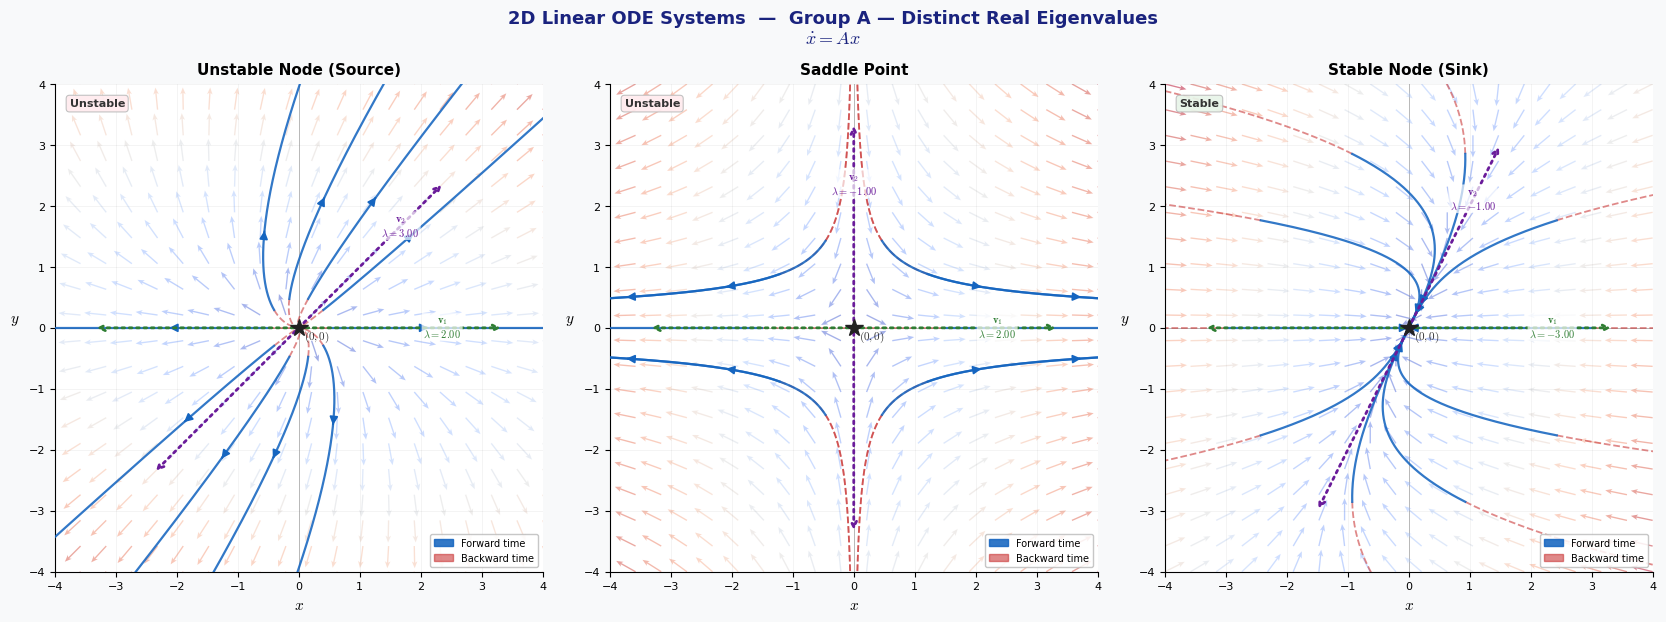

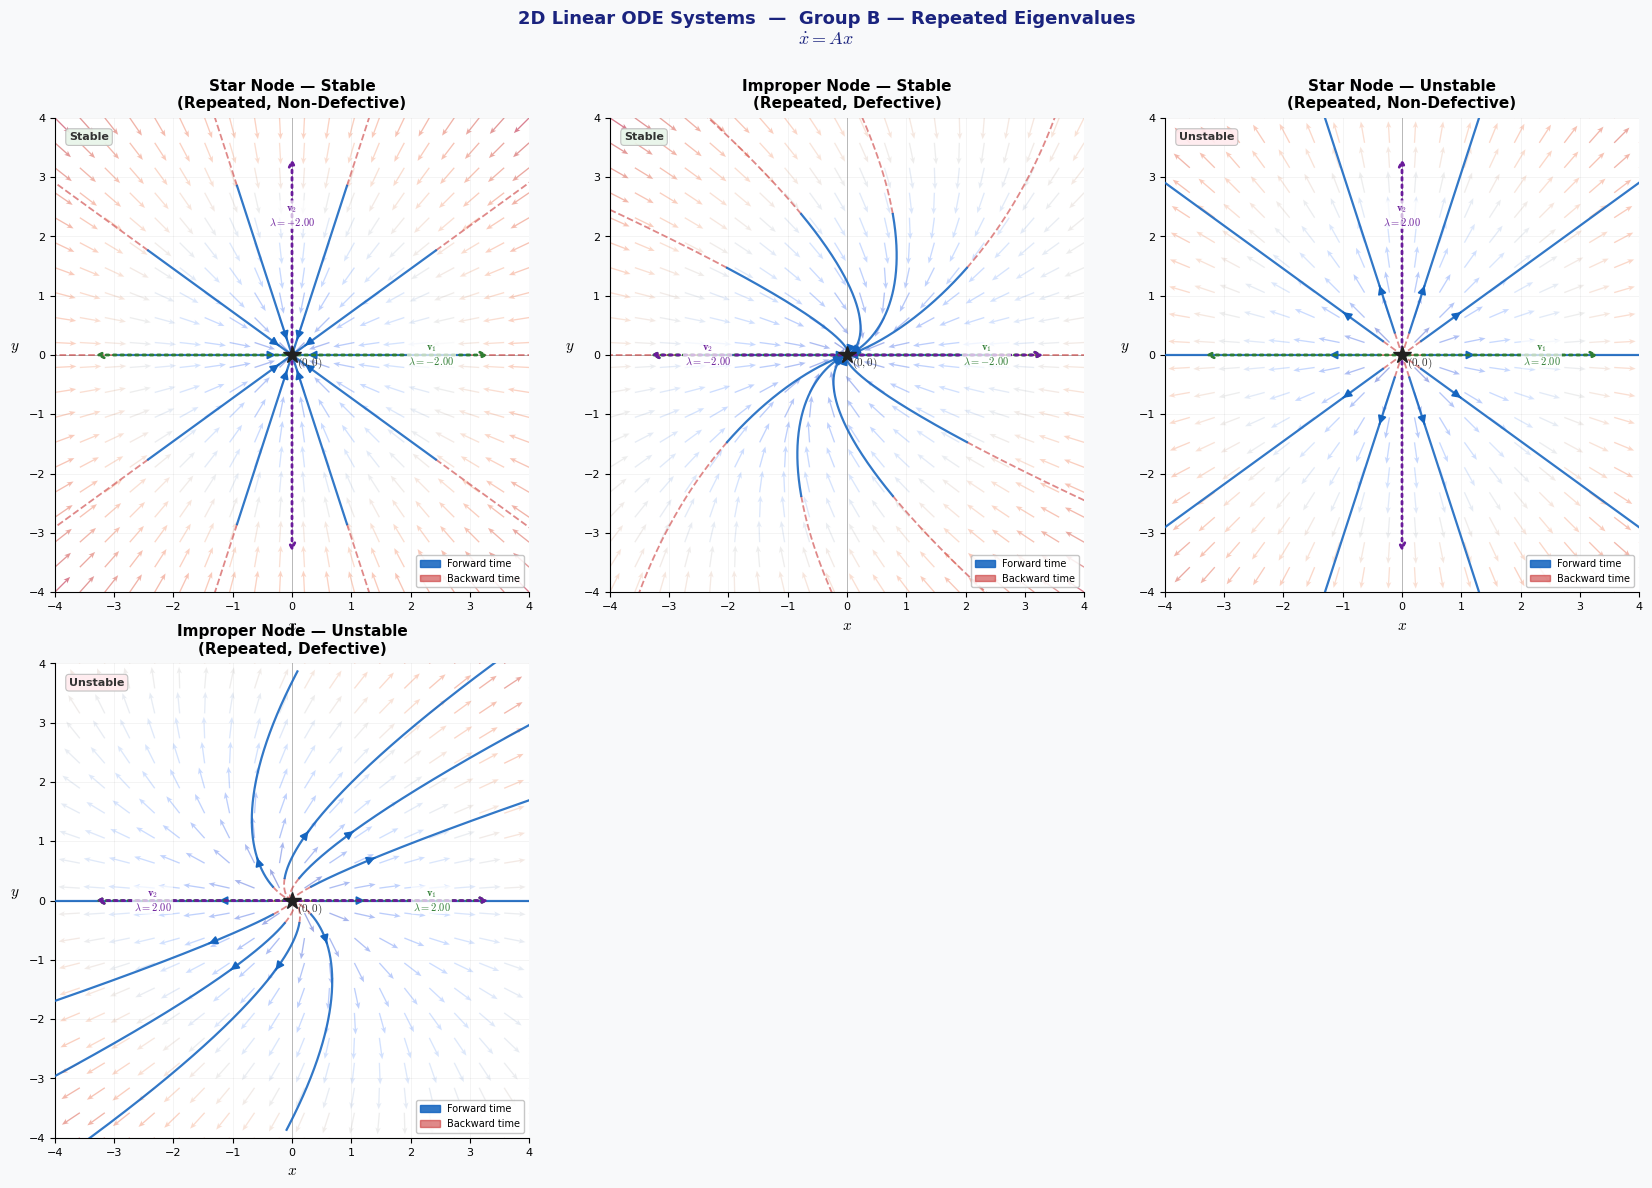

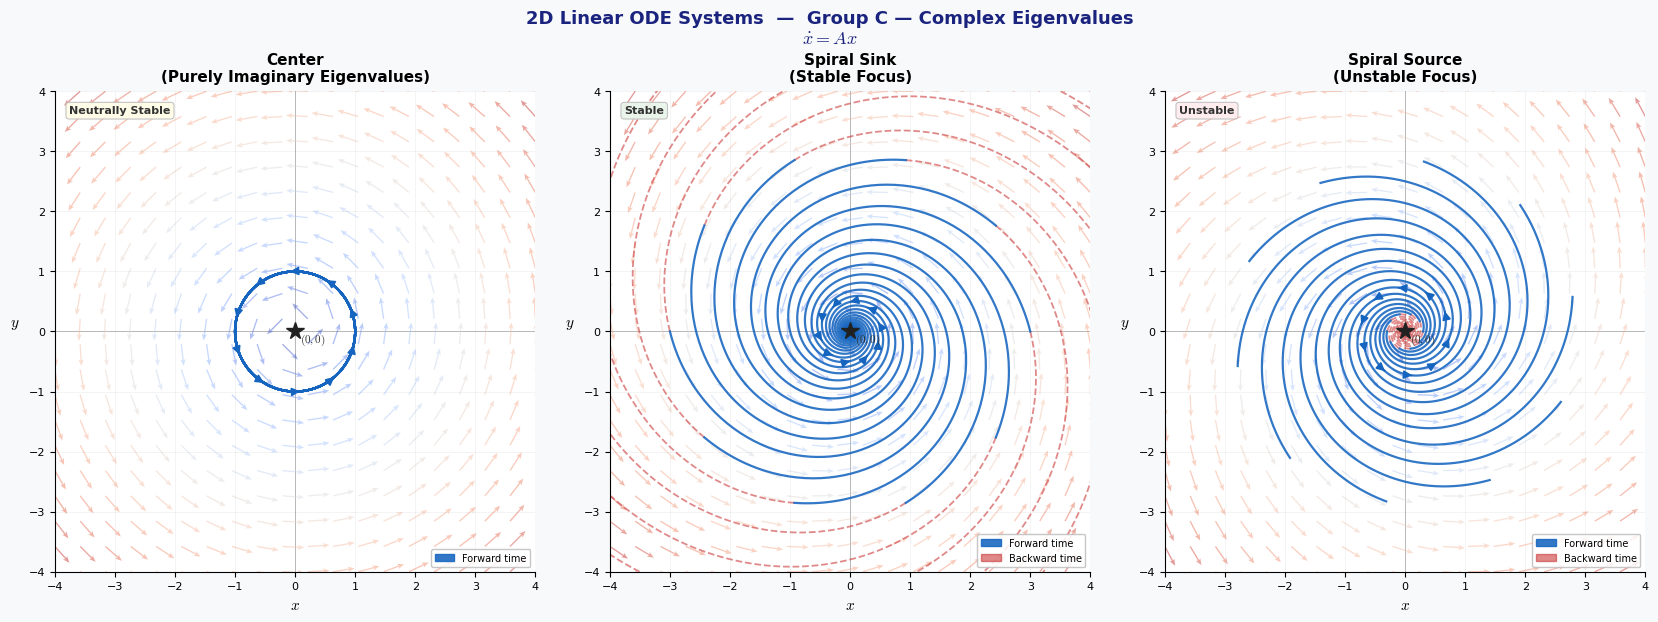

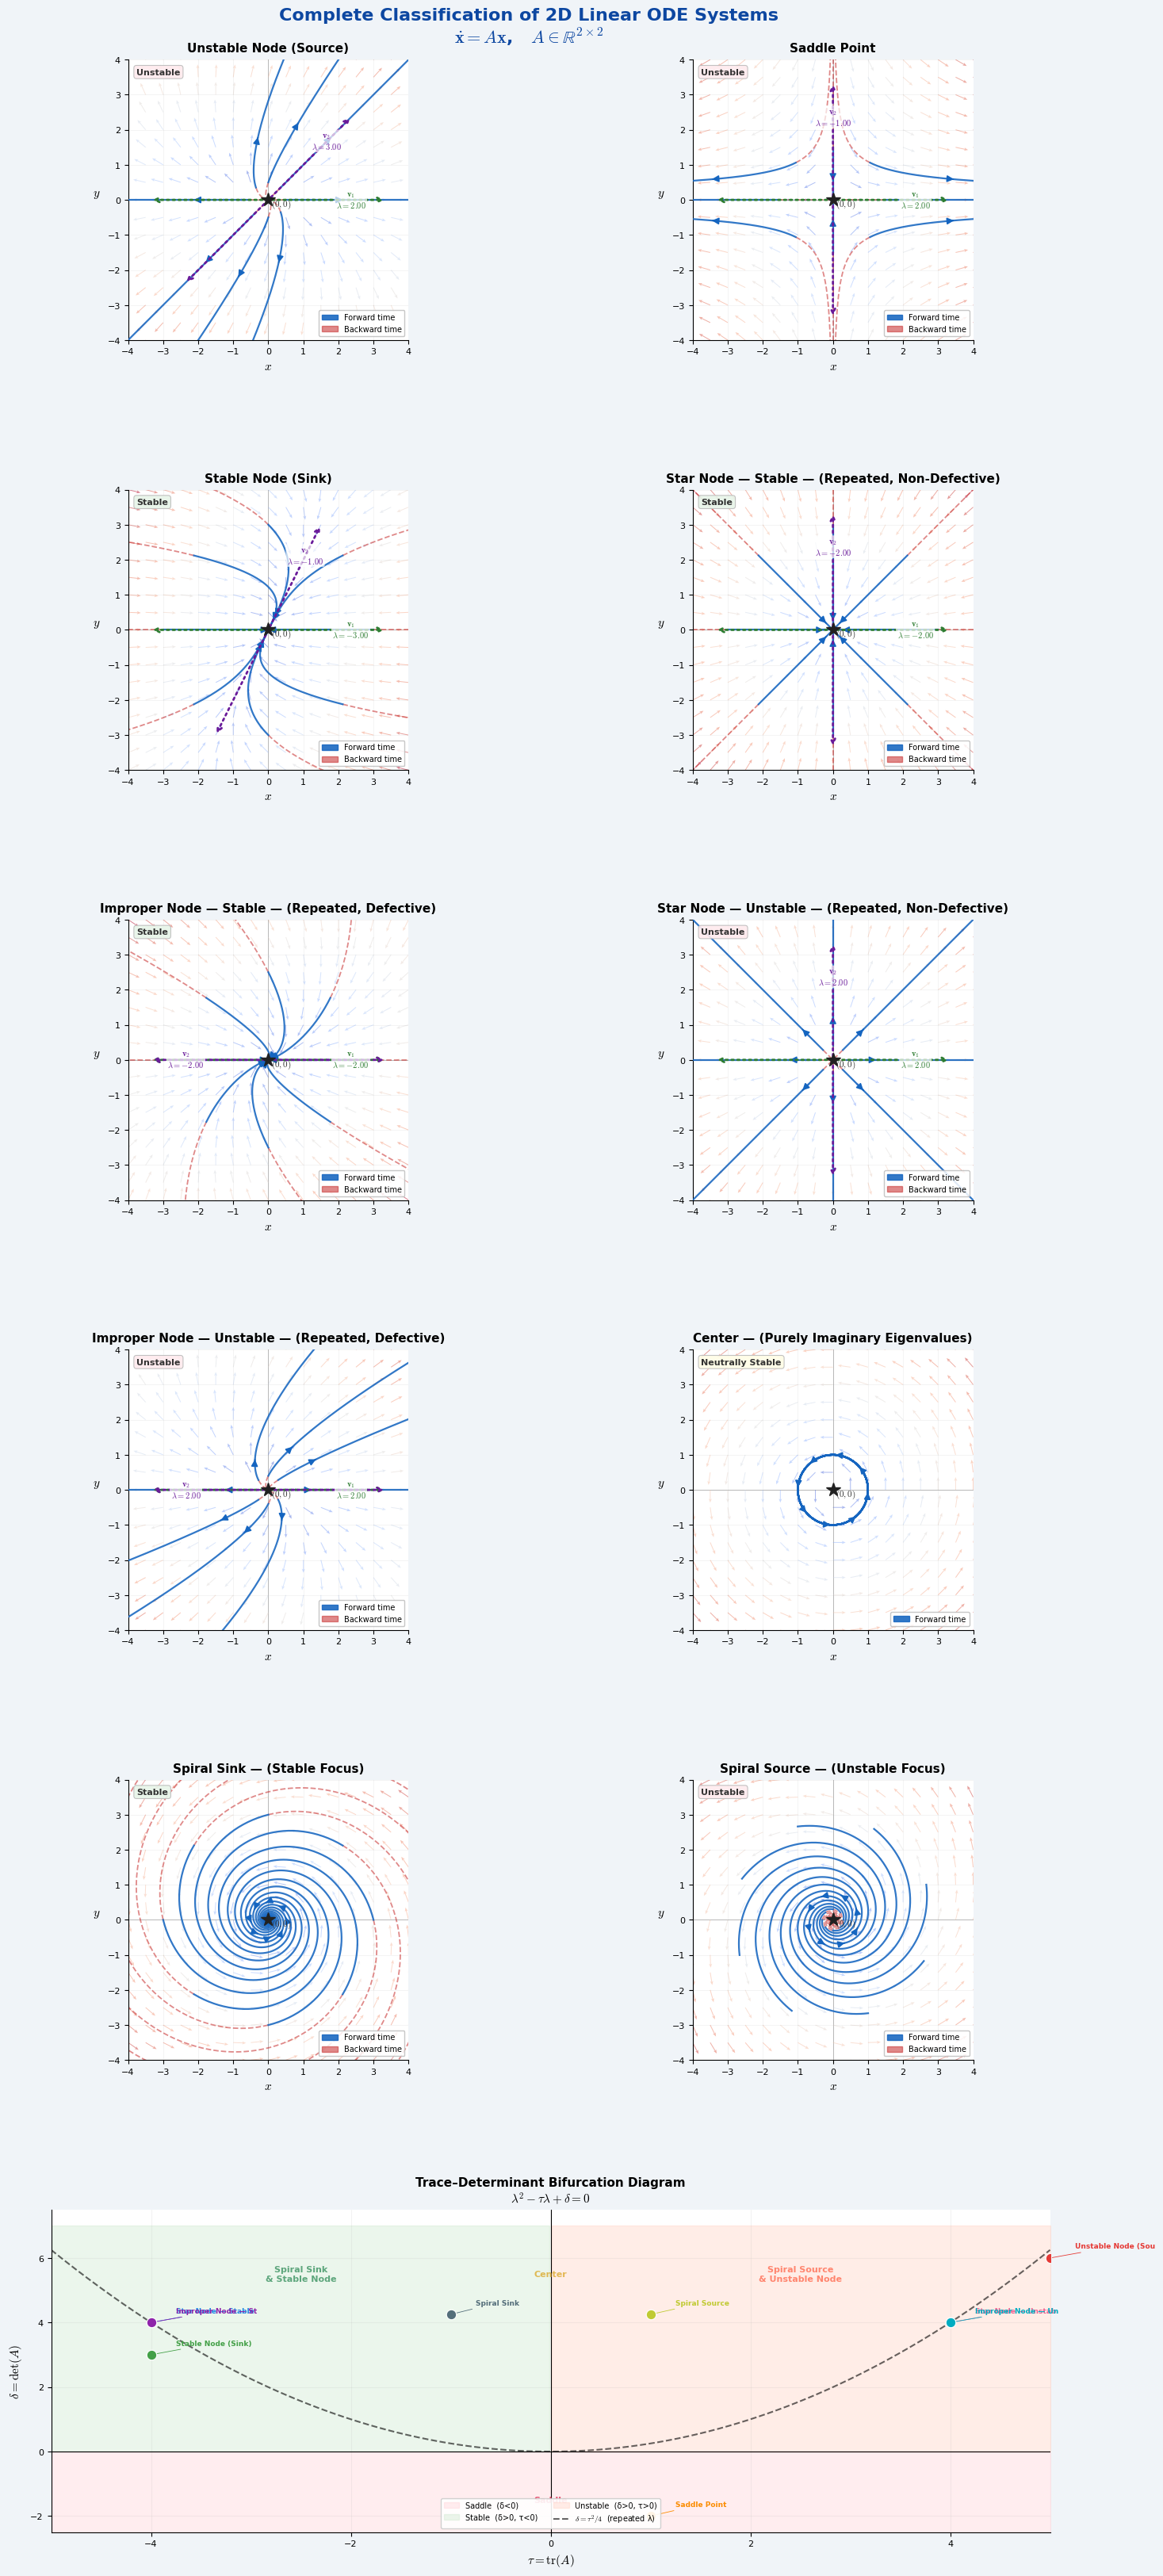


  Done.



In [2]:
"""
╔══════════════════════════════════════════════════════════════════════════════╗
║   PHASE PORTRAIT CLASSIFICATION OF 2D LINEAR AUTONOMOUS ODE SYSTEMS         ║
║   dx/dt = Ax,   A ∈ ℝ²ˣ²                                                    ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  Ten canonical qualitative behaviors at the equilibrium (0,0):               ║
║                                                                              ║
║  GROUP A — Distinct Real Eigenvalues                                         ║
║    1. Unstable Node (Source)          λ₁ > λ₂ > 0                           ║
║    2. Saddle Point                    λ₁ > 0 > λ₂                           ║
║    3. Stable Node (Sink)              0 > λ₁ > λ₂                           ║
║                                                                              ║
║  GROUP B — Repeated Eigenvalues                                              ║
║    4. Star Node — Stable              λ = α < 0, A = αI (non-defective)     ║
║    5. Improper Node — Stable          λ = α < 0, Jordan block (defective)   ║
║    6. Star Node — Unstable            λ = α > 0, A = αI (non-defective)     ║
║    7. Improper Node — Unstable        λ = α > 0, Jordan block (defective)   ║
║                                                                              ║
║  GROUP C — Complex Eigenvalues                                               ║
║    8. Center                          λ = ±βi  (Re = 0)                     ║
║    9. Spiral Sink (Stable Focus)      λ = α ± βi, α < 0                     ║
║   10. Spiral Source (Unstable Focus)  λ = α ± βi, α > 0                     ║
║                                                                              ║
║  BONUS: Trace–Determinant bifurcation diagram                                ║
║                                                                              ║
║  Usage:    python ode_phase_portraits.py                                     ║
║  Requires: numpy  matplotlib  scipy                                          ║
╚══════════════════════════════════════════════════════════════════════════════╝
"""

# ══════════════════════════════════════════════════════════════════════════════
# IMPORTS & GLOBAL CONFIGURATION
# ══════════════════════════════════════════════════════════════════════════════

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.patheffects as pe
from matplotlib.colors import Normalize
from matplotlib.patches import FancyArrowPatch
from scipy.integrate import solve_ivp
import warnings

warnings.filterwarnings("ignore")

# ── Output directory ──────────────────────────────────────────────────────────
# __file__ exists when running as a .py script; falls back to the current
# working directory when running inside a Jupyter notebook or REPL.
try:
    _base = os.path.dirname(os.path.abspath(__file__))
except NameError:
    _base = os.getcwd()

OUTPUT_DIR = os.path.join(_base, "ode_figures")
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"  📁  Figures will be saved to: {OUTPUT_DIR}")

# ── Matplotlib aesthetic settings ─────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor"  : "#F8F9FA",
    "axes.facecolor"    : "#FFFFFF",
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.labelsize"    : 11,
    "axes.titlesize"    : 11,
    "font.family"       : "DejaVu Sans",
    "mathtext.fontset"  : "cm",
    "xtick.labelsize"   : 8,
    "ytick.labelsize"   : 8,
})

# ── Consistent color palette used throughout ──────────────────────────────────
PAL = {
    "fwd"        : "#1565C0",   # forward-time trajectories  (rich blue)
    "bwd"        : "#C62828",   # backward-time trajectories (deep red)
    "eq"         : "#212121",   # equilibrium marker         (near-black)
    "eig1"       : "#2E7D32",   # first eigenvector          (forest green)
    "eig2"       : "#6A1B9A",   # second eigenvector         (deep purple)
    "field_cmap" : "coolwarm",
    "stable"     : "#E8F5E9",   # badge background — stable
    "unstable"   : "#FFEBEE",   # badge background — unstable
    "neutral"    : "#FFFDE7",   # badge background — neutrally stable
}


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 1 ─ CORE MATHEMATICAL FUNCTIONS
# ══════════════════════════════════════════════════════════════════════════════

def system_ode(t, state, A):
    """
    Right-hand side of the autonomous linear ODE:  d(state)/dt = A · state.

    The system is autonomous (A is constant in time), so t is only present
    to satisfy the interface expected by scipy.integrate.solve_ivp.

    Parameters
    ----------
    t     : float        Current time (not used internally)
    state : ndarray (2,) Current state vector [x, y]ᵀ
    A     : ndarray (2,2) Constant system matrix

    Returns
    -------
    ndarray (2,) : [dx/dt, dy/dt]ᵀ = A @ [x, y]ᵀ
    """
    return A @ state


def compute_eigenanalysis(A, verbose=True):
    """
    Compute eigenvalues and right eigenvectors of matrix A, and optionally
    print a formatted diagnostic report to the console.

    The characteristic equation is:
        λ² − tr(A)·λ + det(A) = 0
    with discriminant  Δ = tr(A)² − 4·det(A).

    Parameters
    ----------
    A       : ndarray (2,2) System matrix
    verbose : bool          When True, print the formatted report

    Returns
    -------
    eigenvalues  : ndarray (2,) complex — eigenvalues of A
    eigenvectors : ndarray (2,2)         columns are right eigenvectors
    """
    eigenvalues, eigenvectors = np.linalg.eig(A)
    tr   = float(np.trace(A))
    det  = float(np.linalg.det(A))
    disc = tr**2 - 4.0 * det

    if verbose:
        w = 56
        print(f"\n  ┌{'─'*w}┐")
        print(f"  │{'Matrix A':^{w}}│")
        print(f"  ├{'─'*w}┤")
        print(f"  │   ⎡{A[0,0]:+9.4f}  {A[0,1]:+9.4f} ⎤{'':>25}│")
        print(f"  │   ⎣{A[1,0]:+9.4f}  {A[1,1]:+9.4f} ⎦{'':>25}│")
        print(f"  ├{'─'*w}┤")
        print(f"  │  tr(A) = {tr:+.4f}      det(A) = {det:+.4f}{'':>18}│")
        print(f"  │  Δ = tr²−4·det  =  {disc:+.4f}{'':>27}│")
        print(f"  ├{'─'*w}┤")
        print(f"  │  Eigenvalues & Eigenvectors:{'':>27}│")
        for i, (lam, vec) in enumerate(zip(eigenvalues, eigenvectors.T)):
            if abs(lam.imag) > 1e-10:
                s = f"λ{i+1} = {lam.real:+.4f} {'+'if lam.imag>=0 else ''}{lam.imag:.4f}i  (complex)"
            else:
                v = vec.real
                s = (f"λ{i+1} = {lam.real:+.4f}   →   "
                     f"v{i+1} = [{v[0]:+.4f}, {v[1]:+.4f}]ᵀ")
            print(f"  │  {s:<{w-2}}│")
        print(f"  └{'─'*w}┘")

    return eigenvalues, eigenvectors


def classify_system(A):
    """
    Automatically classify the qualitative behavior of the equilibrium at
    the origin, using the trace–determinant–discriminant criterion.

    Decision tree  (τ = tr A,  δ = det A,  Δ = τ²−4δ):
    ┌─────────────────────────────────────────────────────────────┐
    │ δ < 0                → Saddle Point                        │
    │ δ > 0, Δ < 0:                                              │
    │    τ = 0             → Center                              │
    │    τ < 0             → Spiral Sink                         │
    │    τ > 0             → Spiral Source                       │
    │ δ > 0, Δ ≈ 0:                                              │
    │    non-defective     → Star Node                           │
    │    defective         → Improper Node (Jordan)              │
    │ δ > 0, Δ > 0:                                              │
    │    τ < 0             → Stable Node                         │
    │    τ > 0             → Unstable Node                       │
    └─────────────────────────────────────────────────────────────┘

    Parameters
    ----------
    A : ndarray (2,2)

    Returns
    -------
    name      : str  Full descriptive classification
    stability : str  'Stable', 'Unstable', or 'Neutrally Stable'
    short     : str  Short label used for plot badges
    """
    tr   = float(np.trace(A))
    det  = float(np.linalg.det(A))
    disc = tr**2 - 4.0 * det

    # ── Saddle: det < 0 ────────────────────────────────────────────────────
    if det < -1e-10:
        return "Saddle Point", "Unstable", "Saddle"

    # ── Complex eigenvalues: discriminant < 0 ──────────────────────────────
    if disc < -1e-10:
        alpha = tr / 2.0          # real part of eigenvalues
        if abs(alpha) < 1e-10:
            return "Center", "Neutrally Stable", "Center"
        if alpha < 0:
            return "Spiral Sink (Stable Focus)", "Stable", "Spiral Sink"
        return "Spiral Source (Unstable Focus)", "Unstable", "Spiral Source"

    # ── Repeated eigenvalue: discriminant ≈ 0 ─────────────────────────────
    if abs(disc) < 1e-8:
        lam = tr / 2.0
        # Defectiveness check: A − λI has rank 1 iff defective
        B = A - lam * np.eye(2)
        defective = np.linalg.matrix_rank(B, tol=1e-7) > 0
        kind = "Defective (Improper Node)" if defective else "Non-Defective (Star Node)"
        stab = "Stable" if lam < -1e-10 else "Unstable"
        return f"Repeated λ={lam:.2f} — {kind}", stab, kind[:4]

    # ── Distinct real eigenvalues: disc > 0, det > 0 ───────────────────────
    if tr < 0:
        return "Stable Node (Sink)", "Stable", "Stable Node"
    return "Unstable Node (Source)", "Unstable", "Unstable Node"


def generate_initial_conditions(n=10, radius=2.5):
    """
    Place n starting points uniformly on a circle of given radius.

    Using a circle ensures all phase-space directions are sampled equally,
    giving a complete picture of the flow geometry.

    Parameters
    ----------
    n      : int    Number of initial conditions
    radius : float  Circle radius (centred at origin)

    Returns
    -------
    list of [x₀, y₀] pairs
    """
    angles = np.linspace(0.0, 2.0 * np.pi, n, endpoint=False)
    return [[radius * np.cos(a), radius * np.sin(a)] for a in angles]


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 2 ─ VECTOR FIELD
# ══════════════════════════════════════════════════════════════════════════════

def compute_vector_field(A, xlim=(-4, 4), ylim=(-4, 4), density=20):
    """
    Evaluate F(x,y) = A·[x,y]ᵀ on a uniform grid and normalise for display.

    Normalisation (dividing by magnitude) gives each arrow the same length,
    which makes the direction of flow legible even far from the origin where
    the field magnitude is very large.

    Parameters
    ----------
    A       : ndarray (2,2) System matrix
    xlim    : (x_min, x_max)
    ylim    : (y_min, y_max)
    density : int  Grid points per axis

    Returns
    -------
    X, Y  : ndarray (density×density) grid coordinates
    U, V  : ndarray                   normalised direction components
    M     : ndarray                   raw magnitudes  (used for colouring)
    """
    x = np.linspace(xlim[0], xlim[1], density)
    y = np.linspace(ylim[0], ylim[1], density)
    X, Y = np.meshgrid(x, y)

    # Linear field:  [dx/dt, dy/dt]ᵀ = A @ [x, y]ᵀ
    U = A[0, 0] * X + A[0, 1] * Y
    V = A[1, 0] * X + A[1, 1] * Y

    M = np.hypot(U, V)                        # vector magnitude at each point
    M_safe = np.where(M < 1e-12, 1.0, M)     # guard against 0/0 at origin

    return X, Y, U / M_safe, V / M_safe, M


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 3 ─ TRAJECTORY SIMULATION
# ══════════════════════════════════════════════════════════════════════════════

def simulate_trajectories(A, initial_conditions,
                           t_span=(0.0, 5.0), n_points=700,
                           both_directions=True):
    """
    Numerically integrate dx/dt = Ax from each initial condition using RK45.

    For each starting point we optionally integrate both:
      • forward  in time (t: 0 → +T) to observe long-term fate of orbits
      • backward in time (t: 0 → −T) to reveal the past history of orbits

    Parameters
    ----------
    A                  : ndarray (2,2)
    initial_conditions : list of [x₀, y₀]
    t_span             : (t₀, T) — forward integration interval
    n_points           : int — evaluation points per trajectory
    both_directions    : bool — also integrate backward if True

    Returns
    -------
    list of dicts, each containing:
        'forward'  : ndarray (2, n_points)
        'backward' : ndarray (2, n_points)  (present only if both_directions)
    """
    t0, T = t_span
    t_fwd = np.linspace(t0,  T, n_points)
    t_bwd = np.linspace(t0, -T, n_points)

    trajectories = []
    for ic in initial_conditions:
        traj = {}

        # ── Forward integration ────────────────────────────────────────────
        sol = solve_ivp(
            system_ode, [t_fwd[0], t_fwd[-1]], ic,
            t_eval=t_fwd, args=(A,),
            method="RK45", rtol=1e-8, atol=1e-10,
        )
        traj["forward"] = sol.y   # shape (2, n_points)

        # ── Backward integration (reverse time, reveals past dynamics) ─────
        if both_directions:
            sol_b = solve_ivp(
                system_ode, [t_bwd[0], t_bwd[-1]], ic,
                t_eval=t_bwd, args=(A,),
                method="RK45", rtol=1e-8, atol=1e-10,
            )
            traj["backward"] = sol_b.y

        trajectories.append(traj)

    return trajectories


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 4 ─ PHASE PORTRAIT PLOTTER
# ══════════════════════════════════════════════════════════════════════════════

def _add_flow_arrow(ax, x, y, frac=0.40, color="#1565C0"):
    """
    Annotate a trajectory with a small directional arrowhead.

    The arrow is placed at position `frac` along the valid (non-NaN) part
    of the trajectory, indicating the direction of the flow.
    """
    valid = np.where(~np.isnan(x))[0]
    if len(valid) < 10:
        return
    idx = valid[int(frac * len(valid))]
    if idx + 1 >= len(x) or np.isnan(x[idx + 1]):
        return
    ax.annotate(
        "",
        xy=(x[idx + 1], y[idx + 1]),
        xytext=(x[idx], y[idx]),
        arrowprops=dict(
            arrowstyle="-|>", color=color,
            lw=1.3, mutation_scale=12,
        ),
        zorder=4,
    )


def _mask_trajectory(xy, clip_factor=5.0, xlim=(-4,4), ylim=(-4,4)):
    """
    Replace out-of-range values with NaN so matplotlib splits the line.

    This prevents long, distracting lines when a trajectory exits the
    axis bounds (common for unstable systems).
    """
    x, y = xy
    cx = clip_factor * abs(xlim[1])
    cy = clip_factor * abs(ylim[1])
    bad = (np.abs(x) > cx) | (np.abs(y) > cy)
    return np.where(bad, np.nan, x), np.where(bad, np.nan, y)


def plot_phase_portrait(A, ax,
                        title="Phase Portrait",
                        xlim=(-4, 4), ylim=(-4, 4),
                        initial_conditions=None,
                        t_span=(0.0, 5.0),
                        grid_density=20,
                        show_eigenvectors=True,
                        both_directions=True):
    """
    Draw a complete phase portrait on a Matplotlib Axes.

    The portrait includes:
      ① Normalised quiver field coloured by magnitude
      ② Forward-time trajectories (blue, solid) with directional arrows
      ③ Backward-time trajectories (red, dashed) when both_directions=True
      ④ Equilibrium point marker at origin
      ⑤ Real eigenvector lines (when eigenvalues are real)
      ⑥ Stability badge (coloured label) and legend

    Parameters
    ----------
    A                 : ndarray (2,2)   System matrix
    ax                : Axes            Target Matplotlib axes
    title             : str             Plot title
    xlim, ylim        : (min, max)      Axis limits
    initial_conditions: list or None    Starting points; auto-generated if None
    t_span            : (t₀, T)        Forward integration interval
    grid_density      : int             Vector field resolution
    show_eigenvectors : bool            Draw eigenvectors if real
    both_directions   : bool            Also integrate backward in time

    Returns
    -------
    ax : Axes  (modified in place and returned)
    """
    # ── ① Vector field ─────────────────────────────────────────────────────
    X, Y, U, V, M = compute_vector_field(A, xlim, ylim, grid_density)
    ax.quiver(
        X, Y, U, V, M,
        cmap=PAL["field_cmap"],
        alpha=0.50,
        scale=22, scale_units="width",
        width=0.0028, headwidth=4, headlength=5, headaxislength=4,
        norm=Normalize(vmin=0.0, vmax=max(M.max(), 1e-6)),
        zorder=1,
    )

    # ── ② & ③ Trajectories ─────────────────────────────────────────────────
    if initial_conditions is None:
        initial_conditions = generate_initial_conditions(n=10, radius=2.5)

    trajs = simulate_trajectories(
        A, initial_conditions, t_span,
        both_directions=both_directions,
    )

    for traj in trajs:
        # Forward trajectory
        xf, yf = _mask_trajectory(traj["forward"], xlim=xlim, ylim=ylim)
        ax.plot(xf, yf, color=PAL["fwd"], lw=1.6, alpha=0.88, zorder=3)
        _add_flow_arrow(ax, xf, yf, frac=0.40, color=PAL["fwd"])

        # Backward trajectory
        if "backward" in traj:
            xb, yb = _mask_trajectory(traj["backward"], xlim=xlim, ylim=ylim)
            ax.plot(xb, yb, color=PAL["bwd"],
                    lw=1.3, alpha=0.55, ls="--", zorder=2)

    # ── ④ Eigenvector lines (only when eigenvalues are real) ───────────────
    if show_eigenvectors:
        vals, vecs = np.linalg.eig(A)
        if np.all(np.abs(vals.imag) < 1e-10):
            eig_colors = [PAL["eig1"], PAL["eig2"]]
            ax_range = 0.42 * min(abs(xlim[1] - xlim[0]),
                                  abs(ylim[1] - ylim[0]))
            for i, (lam, vec, ec) in enumerate(zip(vals, vecs.T, eig_colors)):
                d = vec.real
                d = d / np.linalg.norm(d) if np.linalg.norm(d) > 1e-12 else d
                sc = ax_range
                # Draw double-headed arrow along eigenvector direction
                ax.annotate(
                    "",
                    xy=( d[0]*sc,  d[1]*sc),
                    xytext=(-d[0]*sc, -d[1]*sc),
                    arrowprops=dict(
                        arrowstyle="<->", color=ec,
                        lw=2.0, linestyle="dotted",
                    ),
                    zorder=5,
                )
                # Label with eigenvalue
                tx, ty = d[0]*sc*0.70, d[1]*sc*0.70
                ax.text(
                    tx, ty,
                    f"$\\mathbf{{v}}_{i+1}$\n$\\lambda={lam.real:.2f}$",
                    color=ec, fontsize=7.5, fontweight="bold",
                    ha="center", va="center", zorder=6,
                    bbox=dict(boxstyle="round,pad=0.15",
                              facecolor="white", alpha=0.7, edgecolor="none"),
                )

    # ── ⑤ Equilibrium point ────────────────────────────────────────────────
    ax.plot(0, 0, marker="*", color=PAL["eq"],
            markersize=13, zorder=7, clip_on=False)
    ax.text(
        0.08, -0.18, "$(0,0)$",
        color="#333333", fontsize=8, zorder=8,
    )

    # ── Axes cosmetics ─────────────────────────────────────────────────────
    ax.axhline(0, color="#BDBDBD", lw=0.7, zorder=0)
    ax.axvline(0, color="#BDBDBD", lw=0.7, zorder=0)
    ax.grid(True, alpha=0.12, color="gray", lw=0.5)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect("equal", "box")
    ax.set_xlabel("$x$")
    ax.set_ylabel("$y$", rotation=0, labelpad=10)
    ax.set_title(title, fontsize=11, fontweight="bold", pad=7)

    # ── ⑥ Stability badge ─────────────────────────────────────────────────
    _, stability, _ = classify_system(A)
    badge_color = {
        "Stable"          : PAL["stable"],
        "Unstable"        : PAL["unstable"],
        "Neutrally Stable": PAL["neutral"],
    }.get(stability, "#F5F5F5")
    ax.text(
        0.03, 0.97, stability,
        transform=ax.transAxes,
        fontsize=8, fontweight="bold",
        va="top", ha="left", color="#333333",
        bbox=dict(boxstyle="round,pad=0.30", facecolor=badge_color,
                  alpha=0.92, edgecolor="#BDBDBD", lw=0.8),
        zorder=9,
    )

    # Legend
    handles = [mpatches.Patch(color=PAL["fwd"], alpha=0.88, label="Forward time")]
    if both_directions:
        handles.append(
            mpatches.Patch(color=PAL["bwd"], alpha=0.55, label="Backward time")
        )
    ax.legend(handles=handles, loc="lower right",
              fontsize=7, framealpha=0.85, edgecolor="#BDBDBD")

    return ax


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 5 ─ CASE DEFINITIONS
# ══════════════════════════════════════════════════════════════════════════════

def get_all_cases():
    """
    Return the ten canonical 2D linear system cases as a list of dicts.

    Each dict has the following keys:
        name        : str        descriptive plot title
        group       : str        one of three groups (A, B, C)
        A           : ndarray    system matrix
        t_span      : tuple      (t₀, T) for forward integration
        xlim, ylim  : tuple      axis limits
        ics_radius  : float      initial-condition circle radius
        both_dirs   : bool       integrate backward in time
        description : str        multi-line console description

    Matrix choices are verified so that eigenvalues match the stated values.
    """
    return [

        # ══════════════════════════════════════════════════════════════════
        # GROUP A — DISTINCT REAL EIGENVALUES
        # ══════════════════════════════════════════════════════════════════

        dict(
            name="Unstable Node (Source)",
            group="Group A — Distinct Real Eigenvalues",
            # A = upper-triangular → λ₁=2, λ₂=3
            # Eigenvectors: v₁=[1,0], v₂=[1,1] (non-axis directions visible)
            A=np.array([[2.0, 1.0],
                        [0.0, 3.0]]),
            t_span=(0.0, 1.8),
            xlim=(-4, 4), ylim=(-4, 4),
            ics_radius=0.5,
            both_dirs=True,
            description=(
                "Eigenvalues: λ₁=2, λ₂=3  (both positive)\n"
                "Both eigenvalues positive → all trajectories flee the origin exponentially.\n"
                "Near origin, motion is dominated by the slow mode (λ₁=2); far out, by fast (λ₂=3).\n"
                "General solution:  x(t) = c₁·v₁·e^{2t} + c₂·v₂·e^{3t}\n"
                "Stability: UNSTABLE"
            ),
        ),

        dict(
            name="Saddle Point",
            group="Group A — Distinct Real Eigenvalues",
            # Diagonal → λ₁=2 (x-axis), λ₂=-1 (y-axis)
            # Clearest possible illustration of stable/unstable manifolds
            A=np.array([[ 2.0, 0.0],
                        [ 0.0,-1.0]]),
            t_span=(0.0, 2.5),
            xlim=(-4, 4), ylim=(-4, 4),
            ics_radius=1.5,
            both_dirs=True,
            description=(
                "Eigenvalues: λ₁=2, λ₂=−1  (opposite signs)\n"
                "det(A) < 0 → always a saddle (always unstable).\n"
                "Stable manifold (y-axis, v₂): orbits approach origin along y.\n"
                "Unstable manifold (x-axis, v₁): orbits flee along x.\n"
                "Stability: UNSTABLE (saddle is always unstable)"
            ),
        ),

        dict(
            name="Stable Node (Sink)",
            group="Group A — Distinct Real Eigenvalues",
            # A = upper-triangular → λ₁=-3, λ₂=-1
            # Eigenvectors: v₁=[1,0], v₂=[1,2]
            A=np.array([[-3.0, 1.0],
                        [ 0.0,-1.0]]),
            t_span=(0.0, 5.0),
            xlim=(-4, 4), ylim=(-4, 4),
            ics_radius=3.0,
            both_dirs=True,
            description=(
                "Eigenvalues: λ₁=−3, λ₂=−1  (both negative)\n"
                "Both eigenvalues negative → all trajectories converge to origin.\n"
                "Trajectories approach tangentially to slow eigenvector (λ₂=−1).\n"
                "General solution:  x(t) = c₁·v₁·e^{−3t} + c₂·v₂·e^{−t}\n"
                "Stability: STABLE (asymptotically stable)"
            ),
        ),

        # ══════════════════════════════════════════════════════════════════
        # GROUP B — REPEATED EIGENVALUES
        # ══════════════════════════════════════════════════════════════════

        dict(
            name="Star Node — Stable\n(Repeated, Non-Defective)",
            group="Group B — Repeated Eigenvalues",
            # A = −2·I: every vector is an eigenvector (non-defective)
            A=np.array([[-2.0, 0.0],
                        [ 0.0,-2.0]]),
            t_span=(0.0, 3.0),
            xlim=(-4, 4), ylim=(-4, 4),
            ics_radius=3.0,
            both_dirs=True,
            description=(
                "Eigenvalue: λ=−2  (double, non-defective);   A = −2·I\n"
                "Every nonzero vector is an eigenvector — A is a scalar multiple of I.\n"
                "All trajectories are straight rays converging radially to origin.\n"
                "Solution: x(t) = e^{−2t}·x₀  (pure exponential shrinkage)\n"
                "Stability: STABLE"
            ),
        ),

        dict(
            name="Improper Node — Stable\n(Repeated, Defective)",
            group="Group B — Repeated Eigenvalues",
            # Jordan block J(−2): only one linearly independent eigenvector v=[1,0]
            A=np.array([[-2.0, 1.0],
                        [ 0.0,-2.0]]),
            t_span=(0.0, 5.5),
            xlim=(-4, 4), ylim=(-4, 4),
            ics_radius=2.5,
            both_dirs=True,
            description=(
                "Eigenvalue: λ=−2  (double, defective);   Jordan block J(−2)\n"
                "Only ONE eigenvector: v=[1,0]ᵀ.  No second independent eigenvector.\n"
                "Solution involves polynomial × exponential: (c₁ + c₂t)·e^{−2t}\n"
                "Trajectories bend near origin — characteristic 'curved' improper node.\n"
                "Stability: STABLE"
            ),
        ),

        dict(
            name="Star Node — Unstable\n(Repeated, Non-Defective)",
            group="Group B — Repeated Eigenvalues",
            # A = +2·I: every direction is an eigenvector (unstable version)
            A=np.array([[2.0, 0.0],
                        [0.0, 2.0]]),
            t_span=(0.0, 1.4),
            xlim=(-4, 4), ylim=(-4, 4),
            ics_radius=0.4,
            both_dirs=True,
            description=(
                "Eigenvalue: λ=+2  (double, non-defective);   A = +2·I\n"
                "Every direction is an eigenvector; trajectories expand radially outward.\n"
                "Solution: x(t) = e^{+2t}·x₀  (pure exponential growth)\n"
                "Mirror image of the stable star: time-reversed version of case 4.\n"
                "Stability: UNSTABLE"
            ),
        ),

        dict(
            name="Improper Node — Unstable\n(Repeated, Defective)",
            group="Group B — Repeated Eigenvalues",
            # Jordan block J(+2): one eigenvector, polynomial × exp growth
            A=np.array([[2.0, 1.0],
                        [0.0, 2.0]]),
            t_span=(0.0, 1.4),
            xlim=(-4, 4), ylim=(-4, 4),
            ics_radius=0.4,
            both_dirs=True,
            description=(
                "Eigenvalue: λ=+2  (double, defective);   Jordan block J(+2)\n"
                "Only ONE eigenvector: v=[1,0]ᵀ.\n"
                "Solution: (c₁ + c₂t)·e^{+2t} — super-exponential polynomial growth.\n"
                "Unstable improper node: time-reversed version of case 5.\n"
                "Stability: UNSTABLE"
            ),
        ),

        # ══════════════════════════════════════════════════════════════════
        # GROUP C — COMPLEX EIGENVALUES
        # ══════════════════════════════════════════════════════════════════

        dict(
            name="Center\n(Purely Imaginary Eigenvalues)",
            group="Group C — Complex Eigenvalues",
            # Antisymmetric matrix → λ = ±3i  (pure imaginary, tr=0)
            A=np.array([[ 0.0,-3.0],
                        [ 3.0, 0.0]]),
            t_span=(0.0, 4.5),
            xlim=(-4, 4), ylim=(-4, 4),
            ics_radius=1.0,
            both_dirs=False,   # Closed orbits: backward retraces forward exactly
            description=(
                "Eigenvalues: λ = ±3i  (purely imaginary;  α=0, β=3)\n"
                "tr(A)=0 → Re(λ)=0 → neither growing nor decaying amplitude.\n"
                "All trajectories are closed ellipses (neutrally stable, not asymptotically).\n"
                "Solution: x(t) = c₁·cos(3t)·u + c₂·sin(3t)·w\n"
                "Stability: NEUTRALLY STABLE (Lyapunov stable, not asymptotically stable)"
            ),
        ),

        dict(
            name="Spiral Sink\n(Stable Focus)",
            group="Group C — Complex Eigenvalues",
            # λ = −0.5 ± 2i:  α=−0.5 (damping), β=2 (oscillation)
            A=np.array([[-0.5,-2.0],
                        [ 2.0,-0.5]]),
            t_span=(0.0, 9.0),
            xlim=(-4, 4), ylim=(-4, 4),
            ics_radius=3.0,
            both_dirs=True,
            description=(
                "Eigenvalues: λ = −0.5 ± 2i  (α=−0.5 < 0,  β=2)\n"
                "Negative real part → amplitude decays → spiral converges to origin.\n"
                "Each revolution, the radius shrinks by factor e^{2π·α/β} = e^{−π/2} ≈ 0.208.\n"
                "Solution: x(t) = e^{−0.5t}·[c₁cos(2t) + c₂sin(2t)]\n"
                "Stability: STABLE (asymptotically stable)"
            ),
        ),

        dict(
            name="Spiral Source\n(Unstable Focus)",
            group="Group C — Complex Eigenvalues",
            # λ = +0.5 ± 2i:  α=+0.5 (growth), β=2 (oscillation)
            A=np.array([[0.5,-2.0],
                        [2.0, 0.5]]),
            t_span=(0.0, 4.5),
            xlim=(-4, 4), ylim=(-4, 4),
            ics_radius=0.3,
            both_dirs=True,
            description=(
                "Eigenvalues: λ = +0.5 ± 2i  (α=+0.5 > 0,  β=2)\n"
                "Positive real part → amplitude grows → spiral diverges from origin.\n"
                "Time-reversed version of the spiral sink (case 9).\n"
                "Solution: x(t) = e^{+0.5t}·[c₁cos(2t) + c₂sin(2t)]\n"
                "Stability: UNSTABLE"
            ),
        ),
    ]


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 6 ─ TRACE–DETERMINANT BIFURCATION DIAGRAM  (Bonus)
# ══════════════════════════════════════════════════════════════════════════════

def plot_trace_det_diagram(cases, ax):
    """
    Draw the classical Trace–Determinant (τ–δ) bifurcation diagram and mark
    each of the ten cases with a labelled point.

    The τ–δ plane organises all possible 2D linear systems in terms of two
    scalar invariants:
        τ = tr(A)   (x-axis)
        δ = det(A)  (y-axis)

    Key boundaries:
      • δ = 0              horizontal axis     → saddle ↔ node transition
      • τ = 0              vertical axis       → sink ↔ source transition
      • δ = τ²/4           parabola            → real ↔ complex eigenvalues

    Parameters
    ----------
    cases : list of case dicts
    ax    : matplotlib Axes
    """
    tau = np.linspace(-5, 5, 500)

    # ── Shaded regions ─────────────────────────────────────────────────────
    delta_parab = tau**2 / 4.0

    # Saddle region: δ < 0
    ax.fill_between(tau, -2.5, 0,
                    color="#FFCDD2", alpha=0.35, label="Saddle  (δ<0)")
    # Stable region: δ>0, τ<0
    ax.fill_between(tau[tau < 0], 0, 7,
                    color="#C8E6C9", alpha=0.35, label="Stable  (δ>0, τ<0)")
    # Unstable region: δ>0, τ>0
    ax.fill_between(tau[tau > 0], 0, 7,
                    color="#FFCCBC", alpha=0.35, label="Unstable  (δ>0, τ>0)")
    # Centre line (τ=0, δ>0)
    ax.fill_between([0, 0], 0, 7,
                    color="#FFF9C4", alpha=0.85, lw=0)

    # ── Parabola boundary (Δ = 0: repeated eigenvalue locus) ───────────────
    ax.plot(tau, delta_parab,
            "k--", lw=1.5, alpha=0.6,
            label="$\\delta = \\tau^2/4$  (repeated λ)", zorder=3)

    # ── Axes lines ─────────────────────────────────────────────────────────
    ax.axhline(0, color="k", lw=0.8)
    ax.axvline(0, color="k", lw=0.8)

    # ── Region labels ──────────────────────────────────────────────────────
    region_labels = [
        ( 2.5, 5.5, "Spiral Source\n& Unstable Node",  "tomato"),
        (-2.5, 5.5, "Spiral Sink\n& Stable Node",      "seagreen"),
        ( 0.0, 5.5, "Center",                           "goldenrod"),
        ( 0.0,-1.5, "Saddle",                           "crimson"),
    ]
    for tx, ty, txt, clr in region_labels:
        ax.text(tx, ty, txt, ha="center", va="center",
                fontsize=8, color=clr, fontweight="bold", alpha=0.75)

    # ── Plot each case as a coloured marker ────────────────────────────────
    # Colour cycles to distinguish the ten points
    point_colors = [
        "#E53935","#FB8C00","#43A047","#1E88E5","#8E24AA",
        "#F06292","#00ACC1","#6D4C41","#546E7A","#C0CA33",
    ]
    for case, clr in zip(cases, point_colors):
        A  = case["A"]
        tr = float(np.trace(A))
        dt = float(np.linalg.det(A))

        ax.plot(tr, dt, "o", color=clr, ms=9, zorder=5,
                markeredgecolor="white", markeredgewidth=0.8)
        # Short label  (just number for brevity)
        short = case["name"].split("\n")[0][:18]
        ax.annotate(
            short,
            xy=(tr, dt), xytext=(tr + 0.25, dt + 0.3),
            fontsize=6.5, color=clr, fontweight="bold",
            arrowprops=dict(arrowstyle="-", color=clr, lw=0.6),
        )

    # ── Formatting ─────────────────────────────────────────────────────────
    ax.set_xlim(-5, 5)
    ax.set_ylim(-2.5, 7.5)
    ax.set_xlabel(r"$\tau = \mathrm{tr}(A)$", fontsize=11)
    ax.set_ylabel(r"$\delta = \det(A)$", fontsize=11, labelpad=6)
    ax.set_title("Trace–Determinant Bifurcation Diagram\n"
                 r"$\lambda^2 - \tau\lambda + \delta = 0$",
                 fontsize=11, fontweight="bold")
    ax.legend(loc="lower center", fontsize=7, ncol=2, framealpha=0.9)
    ax.grid(True, alpha=0.15)


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 7 ─ FIGURE BUILDERS
# ══════════════════════════════════════════════════════════════════════════════

def build_group_figure(group_cases, group_name):
    """
    Create a figure with one phase portrait per case in a group.

    Layout: up to 3 columns, enough rows to fit all cases.

    Parameters
    ----------
    group_cases : list of case dicts belonging to this group
    group_name  : str   used as figure suptitle

    Returns
    -------
    fig : matplotlib Figure
    """
    n     = len(group_cases)
    ncols = min(n, 3)
    nrows = (n + ncols - 1) // ncols
    fig   = plt.figure(figsize=(ncols * 5.6, nrows * 5.8),
                       facecolor="#F8F9FA")

    fig.suptitle(
        f"2D Linear ODE Systems  —  {group_name}\n"
        r"$\dot{x} = Ax$",
        fontsize=13, fontweight="bold", color="#1A237E", y=1.01,
    )

    for idx, case in enumerate(group_cases, start=1):
        ax  = fig.add_subplot(nrows, ncols, idx)
        ics = generate_initial_conditions(n=10, radius=case["ics_radius"])
        plot_phase_portrait(
            A=case["A"], ax=ax,
            title=case["name"],
            xlim=case["xlim"], ylim=case["ylim"],
            initial_conditions=ics,
            t_span=case["t_span"],
            both_directions=case.get("both_dirs", True),
        )

    plt.tight_layout()
    return fig


def build_summary_figure(cases):
    """
    Create a single summary figure with all 10 phase portraits in a 5×2 grid,
    plus the trace–determinant diagram in a full-width bottom panel.

    Parameters
    ----------
    cases : list of all 10 case dicts

    Returns
    -------
    fig : matplotlib Figure
    """
    fig = plt.figure(figsize=(14, 33), facecolor="#F0F4F8")

    fig.suptitle(
        "Complete Classification of 2D Linear ODE Systems\n"
        r"$\dot{\mathbf{x}} = A\mathbf{x}$,   $A \in \mathbb{R}^{2 \times 2}$",
        fontsize=16, fontweight="bold",
        color="#0D47A1", y=0.995,
    )

    # 5 rows × 2 cols for phase portraits, then 1 wide row for τ–δ diagram
    gs = gridspec.GridSpec(
        6, 2, figure=fig,
        hspace=0.52, wspace=0.30,
        left=0.07, right=0.97,
        top=0.975, bottom=0.03,
        height_ratios=[1,1,1,1,1, 1.15],
    )

    for idx, case in enumerate(cases):
        row, col = divmod(idx, 2)
        ax  = fig.add_subplot(gs[row, col])
        ics = generate_initial_conditions(n=8, radius=case["ics_radius"])
        plot_phase_portrait(
            A=case["A"], ax=ax,
            title=case["name"].replace("\n", " — "),
            xlim=case["xlim"], ylim=case["ylim"],
            initial_conditions=ics,
            t_span=case["t_span"],
            grid_density=17,
            both_directions=case.get("both_dirs", True),
        )

    # Trace–Determinant diagram spans both columns
    ax_td = fig.add_subplot(gs[5, :])
    plot_trace_det_diagram(cases, ax_td)

    return fig


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 8 ─ CONSOLE OUTPUT HELPERS
# ══════════════════════════════════════════════════════════════════════════════

def print_banner():
    """Print the program header banner."""
    banner = r"""
╔══════════════════════════════════════════════════════════════════╗
║   CLASSIFICATION OF 2D LINEAR ODE SYSTEMS   dx/dt = Ax          ║
║   Educational Phase Portrait Visualizer                          ║
╚══════════════════════════════════════════════════════════════════╝
"""
    print(banner)


def print_case_analysis(case):
    """
    Print the eigenanalysis and description for a single case.

    Parameters
    ----------
    case : dict  one of the case dicts from get_all_cases()
    """
    name = case["name"].replace("\n", " — ")
    print(f"\n  ◆  {name}")
    eigenvalues, _ = compute_eigenanalysis(case["A"], verbose=True)
    full_name, stability, _ = classify_system(case["A"])
    print(f"\n  → Classified as : {full_name}")
    print(f"  → Stability     : {stability}")
    # Print the description lines
    for line in case["description"].splitlines():
        print(f"     {line}")


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 9 ─ MAIN
# ══════════════════════════════════════════════════════════════════════════════

def main():
    """
    Entry point: print eigenanalysis for all ten cases, create per-group
    phase portrait figures, and build the composite summary figure.
    """
    print_banner()

    cases  = get_all_cases()

    # ── Group cases ────────────────────────────────────────────────────────
    groups = {}
    for case in cases:
        groups.setdefault(case["group"], []).append(case)

    # ── Console eigenanalysis ──────────────────────────────────────────────
    for gname, gcases in groups.items():
        print(f"\n{'═'*65}")
        print(f"  {gname.upper()}")
        print(f"{'═'*65}")
        for case in gcases:
            print_case_analysis(case)
            print()   # blank line between cases

    # ── Phase portrait figures (one per group) ─────────────────────────────
    print("\n  Rendering phase portrait figures …\n")

    group_figs = []
    for gname, gcases in groups.items():
        fig = build_group_figure(gcases, gname)
        fname = (gname.lower()
                      .replace(" — ", "_")
                      .replace(" ", "_")
                      .replace("(", "").replace(")", "")
                 + ".png")
        fpath = os.path.join(OUTPUT_DIR, fname)
        fig.savefig(fpath, dpi=150, bbox_inches="tight",
                    facecolor=fig.get_facecolor())
        print(f"  ✓  Saved  {fpath}")
        group_figs.append(fig)

    # ── Summary figure (all 10 + τ–δ diagram) ─────────────────────────────
    print("\n  Building summary figure (all cases + τ–δ diagram) …")
    fig_summary = build_summary_figure(cases)
    summary_path = os.path.join(OUTPUT_DIR, "ode_summary_all_cases.png")
    fig_summary.savefig(
        summary_path,
        dpi=150, bbox_inches="tight",
        facecolor=fig_summary.get_facecolor(),
    )
    print(f"  ✓  Saved  {summary_path}")

    print("\n  All figures saved. Displaying …\n")
    plt.show()
    print("\n  Done.\n")


# ══════════════════════════════════════════════════════════════════════════════
if __name__ == "__main__":
    main()